# CISC 886 — Cloud Computing Project
## Notebook 1: Data Loading & EDA

**Purpose:** Load preprocessed Stack Overflow Q&A data from S3 and generate EDA figures for the report.

**Output:** Saves `train.parquet`, `val.parquet`, and 3 EDA figures to `/content/`

> ⚠️ **Before running:** Runtime → Change runtime type → **T4 GPU** (or CPU is fine for this notebook)

## Cell 1 — Install Dependencies

In [1]:
%%capture
!pip install pandas pyarrow matplotlib boto3
print('✅ Dependencies installed')

## Cell 2 — Configuration

In [2]:
import os

# ── AWS Credentials ───────────────────────────────────────────────────────────
AWS_ACCESS_KEY_ID     = 'AWS_ACCESS_KEY_ID'
AWS_SECRET_ACCESS_KEY = 'AWS_SECRET_ACCESS_KEY'
AWS_SESSION_TOKEN     = 'AWS_SESSION_TOKEN'   # leave as None if not using temp credentials
AWS_REGION            = 'us-east-1'            # change to your bucket region

# ── S3 Bucket & Paths ─────────────────────────────────────────────────────────
S3_BUCKET       = '25wgws-chatbot-data'
S3_TRAIN_PREFIX = 'processed/stackoverflow/train/'
S3_VAL_PREFIX   = 'processed/stackoverflow/validation/'
S3_TEST_PREFIX  = 'processed/stackoverflow/test/'

# ── Sampling ──────────────────────────────────────────────────────────────────
TRAIN_SAMPLE    = 20_000
VAL_SAMPLE      = 2_000
TEST_SAMPLE     = 2_000

# ── Output paths (loaded by Notebook 2) ──────────────────────────────────────
TRAIN_PARQUET   = 'train.parquet'
VAL_PARQUET     = 'val.parquet'
TEST_PARQUET    = 'test.parquet'

print('✅ Configuration ready')

✅ Configuration ready


## Cell 3 — Load Preprocessed Data from S3 (AWS Credentials)

> Data was produced by the PySpark preprocessing pipeline on AWS EMR.  
> Fill in your credentials in **Cell 2** before running.

In [3]:
import boto3
import pandas as pd
import random
from io import BytesIO

# ── Create S3 client with credentials ────────────────────────────────────────
s3 = boto3.client(
    's3',
    region_name          = AWS_REGION,
    aws_access_key_id    = AWS_ACCESS_KEY_ID,
    aws_secret_access_key= AWS_SECRET_ACCESS_KEY,
    aws_session_token    = AWS_SESSION_TOKEN,
)

def list_parquet_keys(bucket, prefix):
    """List all .parquet object keys under a given S3 prefix."""
    paginator = s3.get_paginator('list_objects_v2')
    keys = []
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get('Contents', []):
            if obj['Key'].endswith('.parquet'):
                keys.append(obj['Key'])
    return keys

def load_parquet_from_s3(bucket, prefix, sample_n, label):
    """
    Download ALL parquet files from S3 prefix, concatenate them,
    then draw a random sample of size sample_n.
    This ensures the sample is truly random across the full dataset.
    """
    all_keys = list_parquet_keys(bucket, prefix)
    print(f'  Found {len(all_keys)} parquet files in s3://{bucket}/{prefix}')

    frames = []
    for i, key in enumerate(all_keys):
        print(f'  [{i+1}/{len(all_keys)}] Downloading {label}: {key.split("/")[-1]}')
        obj = s3.get_object(Bucket=bucket, Key=key)
        frames.append(pd.read_parquet(BytesIO(obj['Body'].read())))

    combined = pd.concat(frames, ignore_index=True)
    print(f'  Total rows before sampling: {len(combined):,}')

    if sample_n >= len(combined):
        print(f'  ⚠️  Requested {sample_n:,} samples but only {len(combined):,} available — using all.')
        return combined.sample(frac=1, random_state=42).reset_index(drop=True)

    return combined.sample(n=sample_n, random_state=42).reset_index(drop=True)

print('📦 Loading training data...')
df_train = load_parquet_from_s3(S3_BUCKET, S3_TRAIN_PREFIX, TRAIN_SAMPLE, 'train')

print('\n📦 Loading validation data...')
df_val = load_parquet_from_s3(S3_BUCKET, S3_VAL_PREFIX, VAL_SAMPLE, 'validation')

print('\n📦 Loading test data...')
df_test = load_parquet_from_s3(S3_BUCKET, S3_TEST_PREFIX, TEST_SAMPLE, 'test')

print(f'\n✅ Train:      {len(df_train):,} samples')
print(f'✅ Validation: {len(df_val):,} samples')
print(f'✅ Test:       {len(df_test):,} samples')
print(f'\n📋 Columns: {list(df_train.columns)}')
print(f'\n📝 Sample row:')
print(df_train[['instruction','input','output']].iloc[0].to_string())

📦 Loading training data...
  Found 200 parquet files in s3://25wgws-chatbot-data/processed/stackoverflow/train/
  [1/200] Downloading train: part-00000-9c5a4f99-f159-43fa-abb9-7cb7cf5199b7-c000.snappy.parquet
  [2/200] Downloading train: part-00001-9c5a4f99-f159-43fa-abb9-7cb7cf5199b7-c000.snappy.parquet
  [3/200] Downloading train: part-00002-9c5a4f99-f159-43fa-abb9-7cb7cf5199b7-c000.snappy.parquet
  [4/200] Downloading train: part-00003-9c5a4f99-f159-43fa-abb9-7cb7cf5199b7-c000.snappy.parquet
  [5/200] Downloading train: part-00004-9c5a4f99-f159-43fa-abb9-7cb7cf5199b7-c000.snappy.parquet
  [6/200] Downloading train: part-00005-9c5a4f99-f159-43fa-abb9-7cb7cf5199b7-c000.snappy.parquet
  [7/200] Downloading train: part-00006-9c5a4f99-f159-43fa-abb9-7cb7cf5199b7-c000.snappy.parquet
  [8/200] Downloading train: part-00007-9c5a4f99-f159-43fa-abb9-7cb7cf5199b7-c000.snappy.parquet
  [9/200] Downloading train: part-00008-9c5a4f99-f159-43fa-abb9-7cb7cf5199b7-c000.snappy.parquet
  [10/200] Down

## Cell 4 — Save Data Locally (for Notebook 2)

In [4]:
df_train.to_parquet(TRAIN_PARQUET, index=False)
df_val.to_parquet(VAL_PARQUET, index=False)
df_test.to_parquet(TEST_PARQUET, index=False)

print(f'✅ Train data saved → {TRAIN_PARQUET}')
print(f'✅ Val data saved   → {VAL_PARQUET}')
print(f'✅ Test data saved  → {TEST_PARQUET}')
print('\n💡 Download these three files and re-upload them in Notebook 2')

✅ Train data saved → train.parquet
✅ Val data saved   → val.parquet
✅ Test data saved  → test.parquet

💡 Download these three files and re-upload them in Notebook 2


## Cell 5 — EDA Figures for the Report

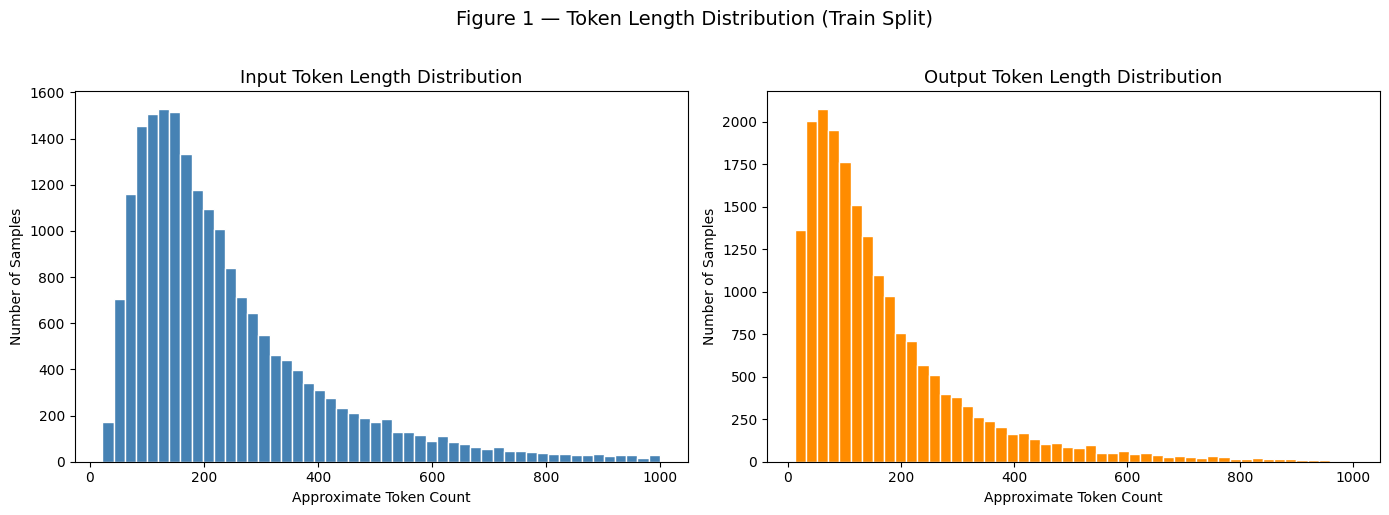

✅ Figure 1 saved


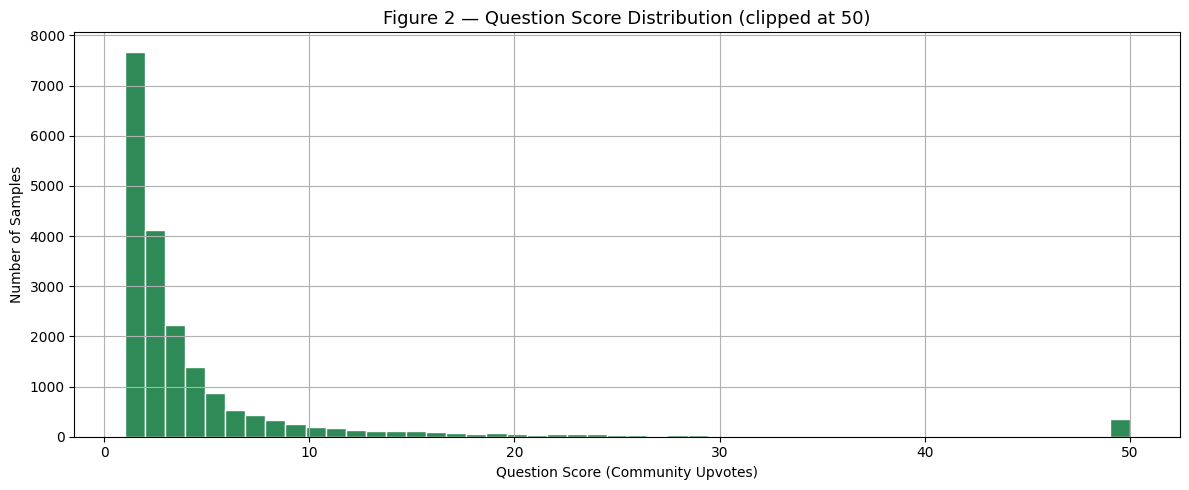

✅ Figure 2 saved


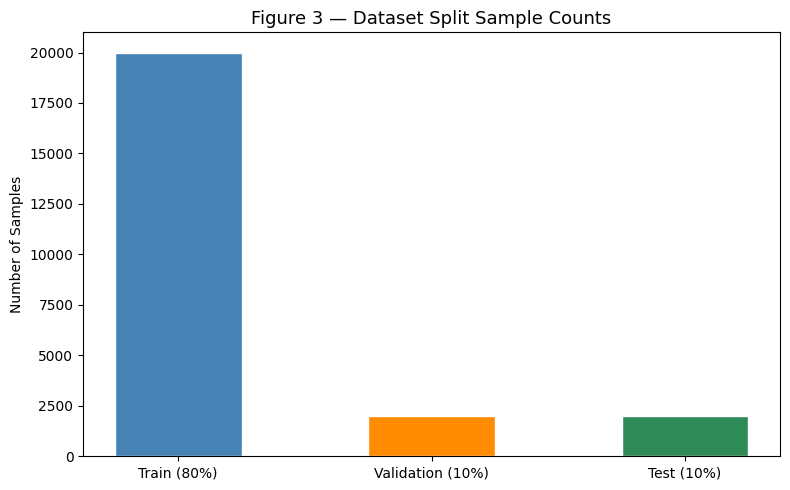

✅ Figure 3 saved

📁 Download figures from the Files panel on the left


In [5]:
import matplotlib.pyplot as plt

# Use precomputed length columns from the PySpark EMR pipeline
df_train['input_tokens']  = df_train['input_len']  / 4
df_train['output_tokens'] = df_train['output_len'] / 4

# ── Figure 1 — Token Length Distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_train['input_tokens'],  bins=50, color='steelblue',  edgecolor='white')
axes[0].set_title('Input Token Length Distribution',  fontsize=13)
axes[0].set_xlabel('Approximate Token Count')
axes[0].set_ylabel('Number of Samples')
axes[1].hist(df_train['output_tokens'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Output Token Length Distribution', fontsize=13)
axes[1].set_xlabel('Approximate Token Count')
axes[1].set_ylabel('Number of Samples')
plt.suptitle('Figure 1 — Token Length Distribution (Train Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/figure1_token_lengths.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 1 saved')

# ── Figure 2 — Question Score Distribution ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
df_train['question_score'].clip(upper=50).hist(bins=50, ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Figure 2 — Question Score Distribution (clipped at 50)', fontsize=13)
ax.set_xlabel('Question Score (Community Upvotes)')
ax.set_ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('/content/figure2_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 2 saved')

# ── Figure 3 — Dataset Split Counts ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    ['Train (80%)', 'Validation (10%)', 'Test (10%)'],
    [len(df_train), len(df_val), len(df_test)],
    color=['steelblue','darkorange','seagreen'], edgecolor='white', width=0.5
)
ax.set_title('Figure 3 — Dataset Split Sample Counts', fontsize=13)
ax.set_ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('/content/figure3_split_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 3 saved')

print('\n📁 Download figures from the Files panel on the left')